  ЛАБОРАТОРНАЯ РАБОТА 20
  SA vs ACO для задачи коммивояжёра

  ЭКСПЕРИМЕНТ 1: 10 городов
  SA Геометр.: L = 29, время = 0.132 с
  SA Логарифм.: L = 36, время = 0.003 с
  SA Сверхбыстр.: L = 35, время = 0.005 с
  ACO (AS): L = 29, время = 0.251 с
  Сохранён: 10cities_convergence.png


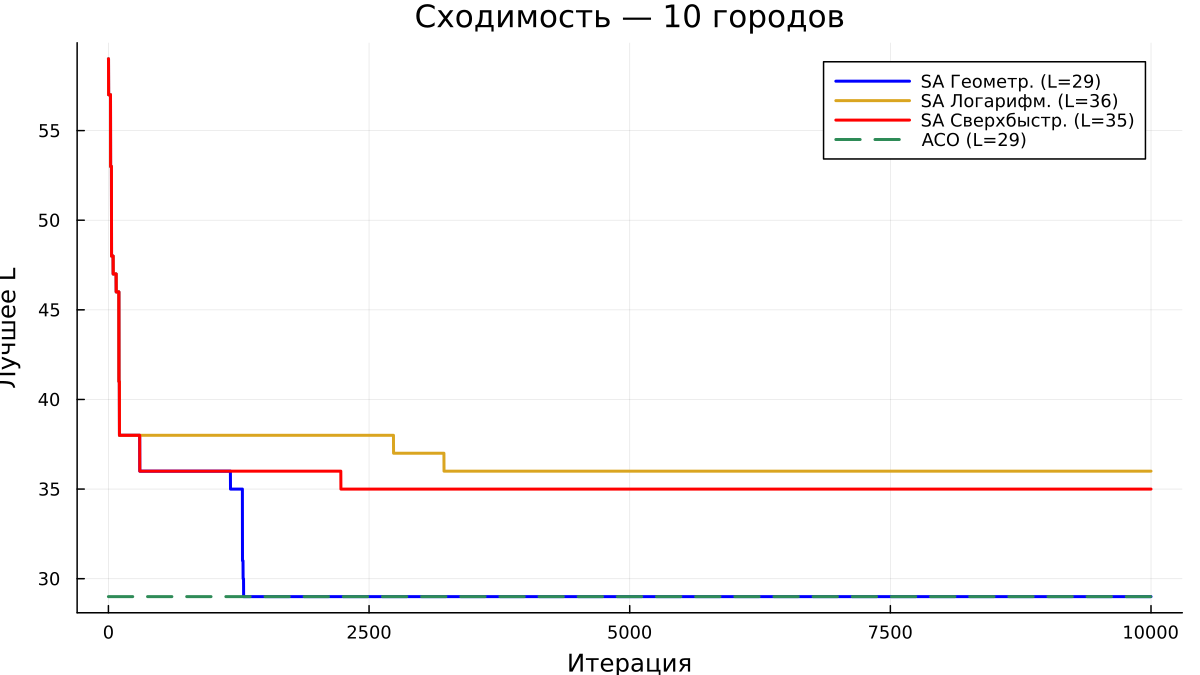

  Сохранён: 10cities_tours.png


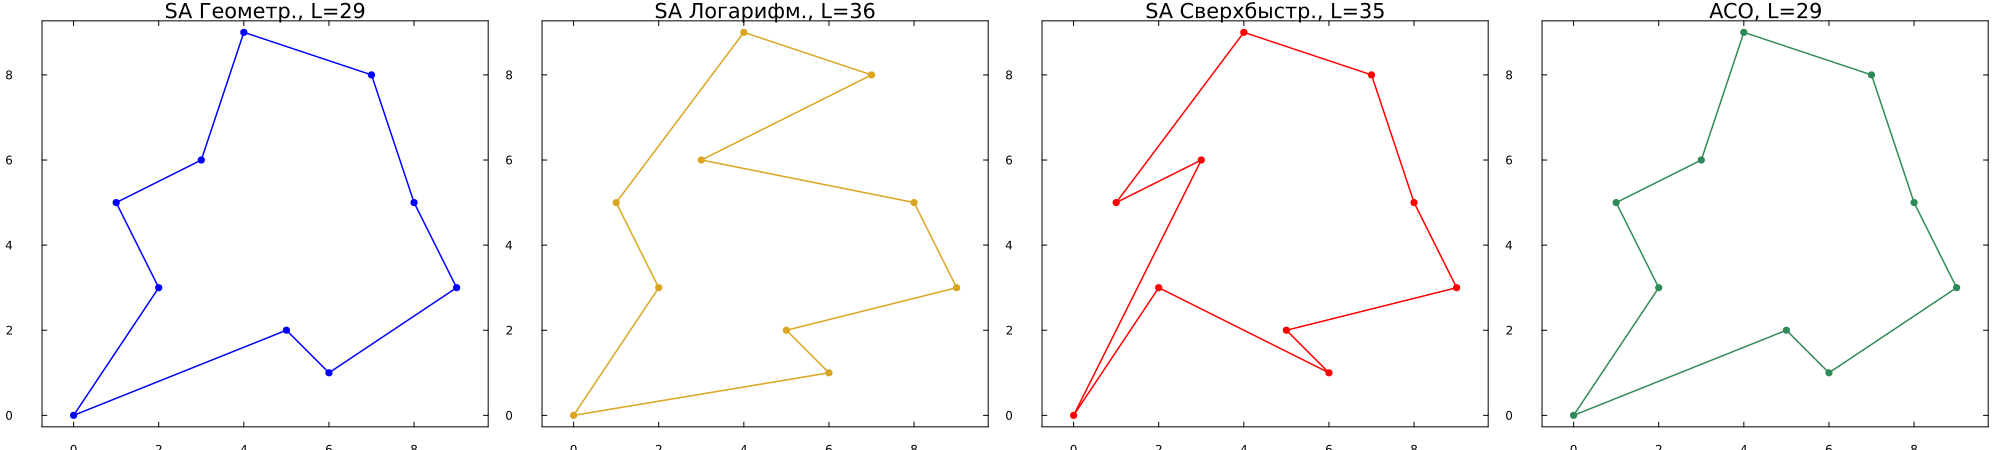


  Алгоритм                    L   Время, с
  --------------------------------------
  SA Геометр.                29      0.132
  SA Логарифм.               36      0.003
  SA Сверхбыстр.             35      0.005
  ACO (AS)                   29      0.251
  GIF: lab20\sa_геометр._10_городов.gif


[ Info: Saved animation to c:\programming\optimization-methods\lab20\sa_геометр._10_городов.gif


  GIF: lab20\sa_логарифм._10_городов.gif


[ Info: Saved animation to c:\programming\optimization-methods\lab20\sa_логарифм._10_городов.gif


  GIF: lab20\sa_сверхбыстр._10_городов.gif


[ Info: Saved animation to c:\programming\optimization-methods\lab20\sa_сверхбыстр._10_городов.gif


  GIF: lab20\aco_10_городов.gif


[ Info: Saved animation to c:\programming\optimization-methods\lab20\aco_10_городов.gif



  ЭКСПЕРИМЕНТ 2: Berlin52 (оптимум = 7542)
  SA Геометр.: L = 7766, время = 0.11 с
  SA Логарифм.: L = 16934, время = 0.11 с
  SA Сверхбыстр.: L = 22261, время = 0.13 с
  ACO (AS): L = 7701, время = 0.33 с
  Сохранён: berlin52_convergence.png


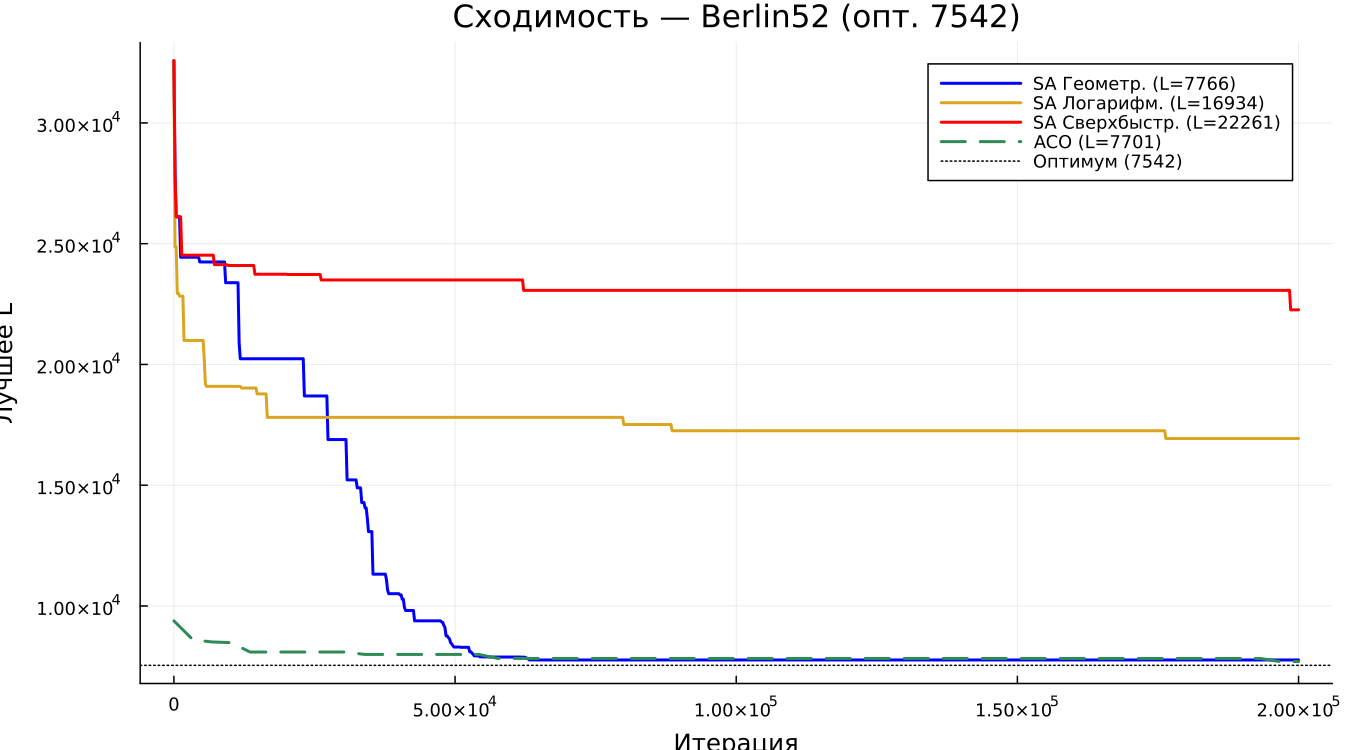

  Сохранён: berlin52_tours.png


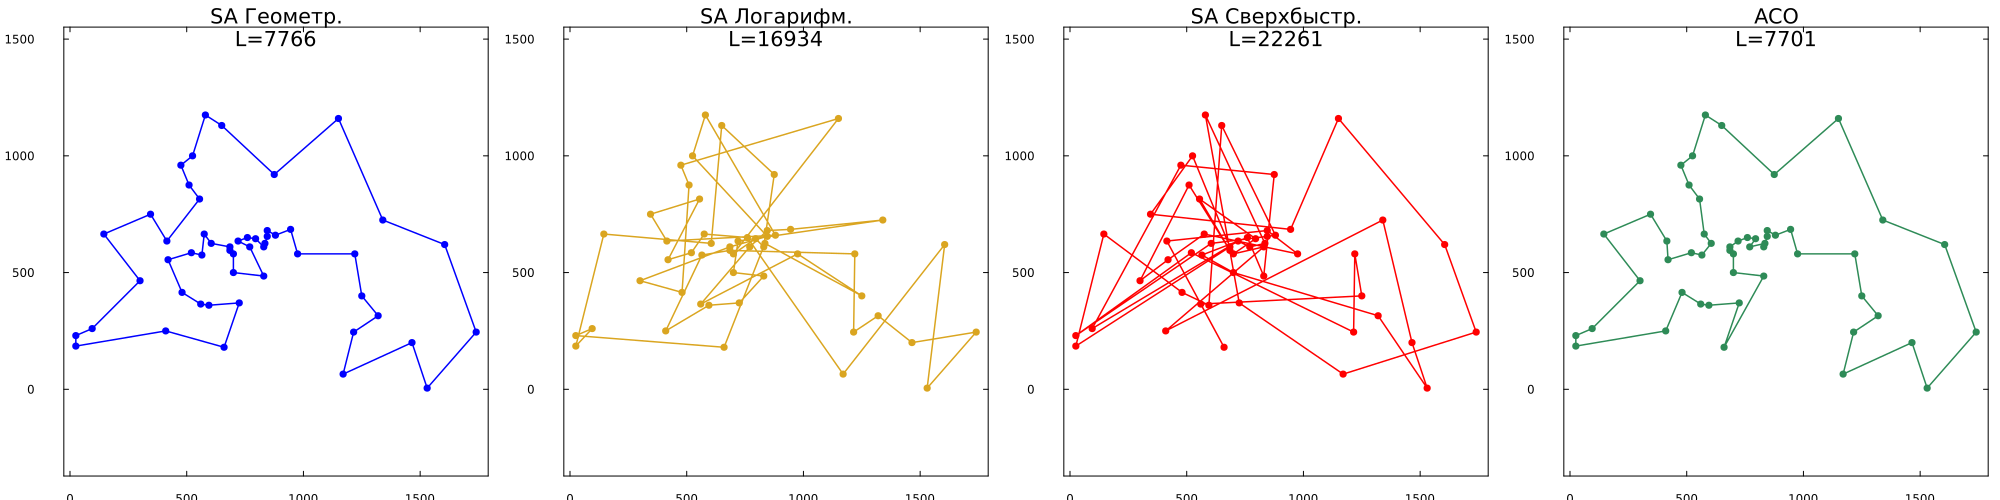

  GIF: lab20\sa_геометр._berlin52.gif


[ Info: Saved animation to c:\programming\optimization-methods\lab20\sa_геометр._berlin52.gif


  GIF: lab20\sa_логарифм._berlin52.gif


[ Info: Saved animation to c:\programming\optimization-methods\lab20\sa_логарифм._berlin52.gif


  GIF: lab20\sa_сверхбыстр._berlin52.gif


[ Info: Saved animation to c:\programming\optimization-methods\lab20\sa_сверхбыстр._berlin52.gif


  GIF: lab20\aco_berlin52.gif

  Алгоритм                    L  Δ от опт.   Время, с
  ------------------------------------------------
  SA Геометр.              7766      +3.0%       0.11
  SA Логарифм.            16934    +124.5%       0.11
  SA Сверхбыстр.          22261    +195.2%       0.13
  ACO (AS)                 7701      +2.1%       0.33

Готово! Все файлы в lab20/


[ Info: Saved animation to c:\programming\optimization-methods\lab20\aco_berlin52.gif


In [2]:
using Plots, Random

OUTPUT_DIR = "lab20"
mkpath(OUTPUT_DIR)

# ==================== ДАННЫЕ ====================

# 10 городов (простой пример)
CITIES_10 = [
    0.0 0.0;  1.0 5.0;  5.0 2.0;  7.0 8.0;  3.0 6.0;
    6.0 1.0;  8.0 5.0;  2.0 3.0;  4.0 9.0;  9.0 3.0
]

# Berlin52
CITIES_52 = [
    565.0 575.0;  25.0 185.0; 345.0 750.0; 945.0 685.0; 845.0 655.0;
    880.0 660.0;  25.0 230.0; 525.0 1000.0; 580.0 1175.0; 650.0 1130.0;
    1605.0 620.0; 1220.0 580.0; 1465.0 200.0; 1530.0 5.0; 845.0 680.0;
    725.0 370.0; 145.0 665.0; 415.0 635.0; 510.0 875.0; 560.0 365.0;
    300.0 465.0; 520.0 585.0; 480.0 415.0; 835.0 625.0; 975.0 580.0;
    1215.0 245.0; 1320.0 315.0; 1250.0 400.0; 660.0 180.0; 410.0 250.0;
    420.0 555.0; 575.0 665.0; 1150.0 1160.0; 700.0 580.0; 685.0 595.0;
    685.0 610.0; 770.0 610.0; 795.0 645.0; 720.0 635.0; 760.0 650.0;
    475.0 960.0; 95.0 260.0; 875.0 920.0; 700.0 500.0; 555.0 815.0;
    830.0 485.0; 1170.0 65.0; 830.0 610.0; 605.0 625.0; 595.0 360.0;
    1340.0 725.0; 1740.0 245.0
]
OPT_52 = 7542

# ==================== МАТРИЦА РАССТОЯНИЙ ====================

function dist_matrix(cities)
    n = size(cities, 1)
    D = zeros(Int, n, n)
    for i in 1:n, j in 1:n
        dx = cities[i,1] - cities[j,1]
        dy = cities[i,2] - cities[j,2]
        D[i,j] = round(Int, sqrt(dx^2 + dy^2))
    end
    return D
end

function tour_length(tour, D)
    s = 0; n = length(tour)
    for i in 1:n
        s += D[tour[i], tour[mod1(i+1, n)]]
    end
    return s
end

# ==================== SA ДЛЯ TSP ====================

# окрестность: 2-opt swap
function two_opt_swap(tour, i, j)
    new_tour = copy(tour)
    new_tour[i:j] = reverse(tour[i:j])
    return new_tour
end

# SA с тремя законами охлаждения
function sa_tsp(cities, D; T0=1000.0, alpha=0.995, beta=0.05, cooling=:geometric,
                max_iter=50000, seed=42)
    Random.seed!(seed)
    n = size(cities, 1)

    tour = randperm(n)
    cur_len = tour_length(tour, D)
    best_tour = copy(tour)
    best_len = cur_len

    history = [best_len]
    frame_tours = [copy(best_tour)]
    frame_dists = [best_len]

    save_every = max(1, max_iter ÷ 60)

    for t in 1:max_iter
        # температура
        if cooling == :geometric
            T = T0 * alpha^t
        elseif cooling == :logarithmic
            T = T0 / log(t + 2)
        elseif cooling == :vfa
            T = T0 * exp(-beta * t^(1.0/n))
        end
        T = max(T, 1e-15)

        # генерация соседа (2-opt)
        i = rand(2:n)
        j = rand(i:n)
        new_tour = two_opt_swap(tour, i, j)
        new_len = tour_length(new_tour, D)
        delta = new_len - cur_len

        if delta <= 0
            tour = new_tour
            cur_len = new_len
        else
            p = exp(-delta / T)
            if rand() < p
                tour = new_tour
                cur_len = new_len
            end
        end

        if cur_len < best_len
            best_tour = copy(tour)
            best_len = cur_len
        end

        push!(history, best_len)

        if t % save_every == 0 || t == max_iter
            push!(frame_tours, copy(best_tour))
            push!(frame_dists, best_len)
        end
    end

    return best_tour, best_len, history, frame_tours, frame_dists
end

# ==================== ACO ДЛЯ TSP (из лабы 16) ====================

function roulette_select(w)
    r = rand() * sum(w); cs = 0.0
    for i in eachindex(w)
        cs += w[i]
        cs >= r && return i
    end
    return length(w)
end

function build_tour_aco(τ, α_aco, β_aco, D)
    n = size(τ, 1)
    start = rand(1:n)
    visited = falses(n); visited[start] = true
    tour = Vector{Int}(undef, n); tour[1] = start
    for step in 2:n
        cur = tour[step-1]
        cands = Int[]; ws = Float64[]
        for j in 1:n
            !visited[j] || continue
            push!(cands, j)
            push!(ws, (τ[cur,j]^α_aco) * ((1.0/D[cur,j])^β_aco))
        end
        next = cands[roulette_select(ws)]
        tour[step] = next; visited[next] = true
    end
    return tour
end

function aco_tsp(cities, D; n_ants=52, α_aco=1.0, β_aco=5.0, ρ=0.5, Q=100.0,
                 τ0=1e-6, n_gen=60, seed=42)
    Random.seed!(seed)
    n = size(cities, 1)
    τ = fill(τ0, n, n)
    gb_tour = collect(1:n); gb_dist = typemax(Int)
    hist_best = Int[]
    frame_tours = Vector{Int}[]
    frame_dists = Int[]

    for gen in 1:n_gen
        tours = [build_tour_aco(τ, α_aco, β_aco, D) for _ in 1:n_ants]
        lengths = [tour_length(t, D) for t in tours]
        order = sortperm(lengths)
        if lengths[order[1]] < gb_dist
            gb_dist = lengths[order[1]]
            gb_tour = copy(tours[order[1]])
        end
        push!(hist_best, gb_dist)
        push!(frame_tours, copy(gb_tour))
        push!(frame_dists, gb_dist)
        τ .*= (1 - ρ)
        for k in 1:n_ants
            Δ = Q / lengths[k]; t = tours[k]
            for s in 1:n
                a, b = t[s], t[mod1(s+1, n)]
                τ[a,b] += Δ; τ[b,a] += Δ
            end
        end
    end
    return gb_tour, gb_dist, hist_best, frame_tours, frame_dists
end

# ==================== ВИЗУАЛИЗАЦИЯ ====================

function plot_tour(cities, tour, title_str, color)
    xs = [cities[tour, 1]; cities[tour[1], 1]]
    ys = [cities[tour, 2]; cities[tour[1], 2]]
    p = plot(xs, ys, lw=1.5, color=color, label=nothing,
             title=title_str, aspect_ratio=:equal,
             grid=false, framestyle=:box)
    scatter!(p, cities[:,1], cities[:,2], ms=4, color=color,
             markerstrokewidth=0, label=nothing)
    return p
end

function make_gif_tsp(cities, frames, dists, name, color, opt_dist=nothing)
    anim = @animate for gen in 1:length(frames)
        tour = frames[gen]
        xs = [cities[tour, 1]; cities[tour[1], 1]]
        ys = [cities[tour, 2]; cities[tour[1], 2]]

        l = @layout [a{0.55w} b]

        p1 = plot(xs, ys; lw=1.5, color=color, linealpha=0.85,
            label=nothing, title="$name · кадр $gen · L=$(dists[gen])",
            titlefontsize=10, aspect_ratio=:equal, grid=false, framestyle=:box)
        scatter!(p1, cities[:,1], cities[:,2];
            ms=3, color=color, markerstrokewidth=0, label=nothing)

        p2 = plot(1:gen, dists[1:gen];
            lw=2, color=color, label="Лучший",
            xlabel="Кадр", ylabel="Расстояние",
            title="Сходимость", titlefontsize=9,
            xlims=(0, length(frames)+1),
            ylims=(minimum(dists)*0.95, dists[1]*1.05),
            grid=true, gridstyle=:dot, gridalpha=0.3)
        if opt_dist !== nothing
            hline!(p2, [opt_dist]; label="Опт. ($opt_dist)",
                color=:red, linestyle=:dash, lw=1.5)
        end

        plot(p1, p2; layout=l, size=(1000, 450), margin=4Plots.mm)
    end
    path = joinpath(OUTPUT_DIR, "$(replace(lowercase(name), " "=>"_")).gif")
    gif(anim, path; fps=4)
    println("  GIF: $path")
end

# ==================== ЭКСПЕРИМЕНТ 1: 10 ГОРОДОВ ====================

function experiment_10()
    println("\n" * "="^60)
    println("  ЭКСПЕРИМЕНТ 1: 10 городов")
    println("="^60)

    cities = CITIES_10
    D = dist_matrix(cities)

    # SA — три закона
    coolings = [
        (:geometric,    "SA Геометр.",   :blue,      0.995, 0.0),
        (:logarithmic,  "SA Логарифм.",  :goldenrod,  0.0,  0.0),
        (:vfa,          "SA Сверхбыстр.",:red,        0.0,  0.1),
    ]

    results_sa = []
    for (cool, name, color, alpha, beta) in coolings
        t_start = time()
        best_tour, best_len, hist, ft, fd = sa_tsp(cities, D;
            T0=500.0, alpha=alpha, beta=beta, cooling=cool,
            max_iter=10000, seed=42)
        elapsed = time() - t_start
        push!(results_sa, (name=name, color=color, best_len=best_len,
              best_tour=best_tour, hist=hist, ft=ft, fd=fd, time=elapsed))
        println("  $name: L = $best_len, время = $(round(elapsed, digits=4)) с")
    end

    # ACO
    t_start = time()
    best_tour_aco, best_len_aco, hist_aco, ft_aco, fd_aco = aco_tsp(cities, D;
        n_ants=10, n_gen=60, seed=42)
    elapsed_aco = time() - t_start
    println("  ACO (AS): L = $best_len_aco, время = $(round(elapsed_aco, digits=4)) с")

    # --- сходимость ---
    p = plot(title="Сходимость — 10 городов",
             xlabel="Итерация", ylabel="Лучшее L",
             size=(800, 450), dpi=150, legend=:topright)
    for r in results_sa
        plot!(p, 0:length(r.hist)-1, r.hist, color=r.color, lw=2, label="$(r.name) (L=$(r.best_len))")
    end
    # ACO на той же шкале (растянуть поколения)
    aco_xs = range(0, 10000, length=length(hist_aco))
    plot!(p, aco_xs, hist_aco, color=:seagreen, lw=2, linestyle=:dash,
          label="ACO (L=$best_len_aco)")
    savefig(p, joinpath(OUTPUT_DIR, "10cities_convergence.png"))
    println("  Сохранён: 10cities_convergence.png")
    display(p)

    # --- финальные маршруты ---
    plots_tours = []
    for r in results_sa
        push!(plots_tours, plot_tour(cities, r.best_tour, "$(r.name), L=$(r.best_len)", r.color))
    end
    push!(plots_tours, plot_tour(cities, best_tour_aco, "ACO, L=$best_len_aco", :seagreen))
    p_all = plot(plots_tours..., layout=(1, 4), size=(2000, 450))
    savefig(p_all, joinpath(OUTPUT_DIR, "10cities_tours.png"))
    println("  Сохранён: 10cities_tours.png")
    display(p_all)

    # --- таблица ---
    println("\n  $(rpad("Алгоритм", 20)) $(lpad("L", 8)) $(lpad("Время, с", 10))")
    println("  " * "-"^38)
    for r in results_sa
        println("  $(rpad(r.name, 20)) $(lpad(string(r.best_len), 8)) $(lpad(string(round(r.time, digits=4)), 10))")
    end
    println("  $(rpad("ACO (AS)", 20)) $(lpad(string(best_len_aco), 8)) $(lpad(string(round(elapsed_aco, digits=4)), 10))")

    # --- GIF для каждого метода ---
    for r in results_sa
        make_gif_tsp(cities, r.ft, r.fd, "$(r.name) 10 городов", r.color)
    end
    make_gif_tsp(cities, ft_aco, fd_aco, "ACO 10 городов", :seagreen)
end

# ==================== ЭКСПЕРИМЕНТ 2: BERLIN52 ====================

function experiment_berlin52()
    println("\n" * "="^60)
    println("  ЭКСПЕРИМЕНТ 2: Berlin52 (оптимум = $OPT_52)")
    println("="^60)

    cities = CITIES_52
    D = dist_matrix(cities)

    coolings = [
        (:geometric,    "SA Геометр.",    :blue,      0.9999, 0.0),
        (:logarithmic,  "SA Логарифм.",   :goldenrod,  0.0,   0.0),
        (:vfa,          "SA Сверхбыстр.", :red,        0.0,   0.005),
    ]

    results_sa = []
    for (cool, name, color, alpha, beta) in coolings
        t_start = time()
        best_tour, best_len, hist, ft, fd = sa_tsp(cities, D;
            T0=5000.0, alpha=alpha, beta=beta, cooling=cool,
            max_iter=200000, seed=42)
        elapsed = time() - t_start
        push!(results_sa, (name=name, color=color, best_len=best_len,
              best_tour=best_tour, hist=hist, ft=ft, fd=fd, time=elapsed))
        println("  $name: L = $best_len, время = $(round(elapsed, digits=2)) с")
    end

    # ACO (AS) — как в лабе 16
    t_start = time()
    best_tour_aco, best_len_aco, hist_aco, ft_aco, fd_aco = aco_tsp(cities, D;
        n_ants=52, n_gen=60, seed=42)
    elapsed_aco = time() - t_start
    println("  ACO (AS): L = $best_len_aco, время = $(round(elapsed_aco, digits=2)) с")

    # --- сходимость ---
    p = plot(title="Сходимость — Berlin52 (опт. $OPT_52)",
             xlabel="Итерация", ylabel="Лучшее L",
             size=(900, 500), dpi=150, legend=:topright)
    for r in results_sa
        # прореживаем для читаемости
        step = max(1, length(r.hist) ÷ 1000)
        idxs = 1:step:length(r.hist)
        plot!(p, collect(idxs) .- 1, r.hist[idxs], color=r.color, lw=2,
              label="$(r.name) (L=$(r.best_len))")
    end
    aco_xs = range(0, 200000, length=length(hist_aco))
    plot!(p, aco_xs, hist_aco, color=:seagreen, lw=2, linestyle=:dash,
          label="ACO (L=$best_len_aco)")
    hline!(p, [OPT_52]; label="Оптимум ($OPT_52)", color=:black,
           linestyle=:dot, lw=1)
    savefig(p, joinpath(OUTPUT_DIR, "berlin52_convergence.png"))
    println("  Сохранён: berlin52_convergence.png")
    display(p)

    # --- финальные маршруты ---
    plots_tours = []
    for r in results_sa
        push!(plots_tours, plot_tour(cities, r.best_tour, "$(r.name)\nL=$(r.best_len)", r.color))
    end
    push!(plots_tours, plot_tour(cities, best_tour_aco, "ACO\nL=$best_len_aco", :seagreen))
    p_all = plot(plots_tours..., layout=(1, 4), size=(2000, 500))
    savefig(p_all, joinpath(OUTPUT_DIR, "berlin52_tours.png"))
    println("  Сохранён: berlin52_tours.png")
    display(p_all)

    # --- GIF для каждого метода ---
    for r in results_sa
        make_gif_tsp(cities, r.ft, r.fd, "$(r.name) Berlin52", r.color, OPT_52)
    end
    make_gif_tsp(cities, ft_aco, fd_aco, "ACO Berlin52", :seagreen, OPT_52)

    # --- таблица ---
    println("\n  $(rpad("Алгоритм", 20)) $(lpad("L", 8)) $(lpad("Δ от опт.", 10)) $(lpad("Время, с", 10))")
    println("  " * "-"^48)
    for r in results_sa
        gap = round((r.best_len - OPT_52) / OPT_52 * 100, digits=1)
        println("  $(rpad(r.name, 20)) $(lpad(string(r.best_len), 8)) $(lpad("+$(gap)%", 10)) $(lpad(string(round(r.time, digits=2)), 10))")
    end
    gap_aco = round((best_len_aco - OPT_52) / OPT_52 * 100, digits=1)
    println("  $(rpad("ACO (AS)", 20)) $(lpad(string(best_len_aco), 8)) $(lpad("+$(gap_aco)%", 10)) $(lpad(string(round(elapsed_aco, digits=2)), 10))")
end

# ==================== ЗАПУСК ====================

println("="^60)
println("  ЛАБОРАТОРНАЯ РАБОТА 20")
println("  SA vs ACO для задачи коммивояжёра")
println("="^60)

experiment_10()
experiment_berlin52()

println("\n" * "="^60)
println("Готово! Все файлы в $OUTPUT_DIR/")
println("="^60)